# Strategy B vs A Comparison - Accuracy & Hallucination Rate
Strategy A (`opposite_label`): random opposite-label distractor. Strategy B (`llm_negation`): LLM-generated negation of the gold passage. Fixed: `standard` prompt, k=5, 5 models, same poison rates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False   # set False for the full experiment

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPE     = "standard"
TEMPERATURE     = cfg["models"]["temperature"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES      = 3 if DRY_RUN else cfg["evaluation"]["n_examples"]

STRATEGY_LABELS = {
    "opposite_label": "Strategy A (opposite_label)",
    "llm_negation":   "Strategy B (llm_negation)",
}
STRATEGY_COLORS = {
    "opposite_label": "#5C6BC0",
    "llm_negation":   "#FF7043",
}
STRATEGY_STYLES = {
    "opposite_label": "-",
    "llm_negation":   "--",
}

print(f"DRY_RUN={DRY_RUN}  n_examples={N_EXAMPLES}  prompt={PROMPT_TYPE}")
print(f"Grid: {len(POISON_RATES)} rates x 2 strategies x {len(MODELS)} models")

from nb_style import MODEL_LABELS


DRY_RUN=False  n_examples=50  prompt=standard
Grid: 5 rates x 2 strategies x 5 models


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples = all_examples[:N_EXAMPLES]
print(f"Total loaded: {len(all_examples):,}  |  Using: {len(examples)}")

Total loaded: 15,935  |  Using: 50


In [3]:
def build_llm(model: str):
    return HuggingFaceClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)


def run_strategy_sweep(examples, poison_rates, prompt_type, k, embedder, llm,
                       distractor_pool, seed, strategy):
    """Sweep poison_rates for one (model, strategy, prompt_type) triple. Returns list of row dicts."""
    rows = []
    model_name = llm._model
    for poison_rate in poison_rates:
        poisoned = (
            poison_dataset(
                examples, poison_rate=poison_rate, seed=seed,
                strategy=strategy, llm=llm,
            )
            if poison_rate > 0.0
            else examples
        )
        retriever = Retriever(embedder=embedder, k=k)
        metrics = run_scorer(
            examples=poisoned,
            retriever=retriever,
            llm=llm,
            prompt_type=prompt_type,
            distractor_pool_size=distractor_pool,
            seed=seed,
            self_consistency_runs=1,
        )
        rows.append({
            "model": model_name,
            "strategy": strategy,
            "poison_rate": poison_rate,
            "prompt_type": prompt_type,
            **metrics,
        })
        tag = "B" if strategy == "llm_negation" else "A"
        short = model_name.split("/")[-1][:14]
        print(
            f"  [Strategy {tag}]  {short:14s}  "
            f"rate={poison_rate:.2f}  acc={metrics['accuracy']:.3f}"
        )
    return rows

In [4]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE)
all_rows = []

print("Starting strategy comparison sweep ...")
for model_name in MODELS:
    print(f"\n--- Model: {model_name} ---")
    llm = build_llm(model_name)
    with llm:
        for strategy in ["opposite_label", "llm_negation"]:
            all_rows.extend(
                run_strategy_sweep(
                    examples=examples,
                    poison_rates=POISON_RATES,
                    prompt_type=PROMPT_TYPE,
                    k=K,
                    embedder=embedder,
                    llm=llm,
                    distractor_pool=DISTRACTOR_POOL,
                    seed=SEED,
                    strategy=strategy,
                )
            )

embedder.close()
results = pd.DataFrame(all_rows)
print(f"\nSweep done. {len(results)} conditions.")
results

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Starting strategy comparison sweep ...

--- Model: Qwen/Qwen2.5-1.5B-Instruct ---
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.00  acc=0.500
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.25  acc=0.420
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.50  acc=0.500
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.75  acc=0.440
  [Strategy A]  Qwen2.5-1.5B-I  rate=1.00  acc=0.420
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.00  acc=0.500
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.25  acc=0.460
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.50  acc=0.500
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.75  acc=0.440
  [Strategy B]  Qwen2.5-1.5B-I  rate=1.00  acc=0.440

--- Model: google/gemma-2-2b-it ---
  [Strategy A]  gemma-2-2b-it   rate=0.00  acc=0.700
  [Strategy A]  gemma-2-2b-it   rate=0.25  acc=0.660
  [Strategy A]  gemma-2-2b-it   rate=0.50  acc=0.600
  [Strategy A]  gemma-2-2b-it   rate=0.75  acc=0.580
  [Strategy A]  gemma-2-2b-it   rate=1.00  acc=0.540
  [Strategy B]  gemma-2-2b-it   rate=0.00  acc=0.700
  [Strategy B]  gemma-2-2b-it   r

,model,strategy,poison_rate,prompt_type,accuracy,macro_f1,hallucination_rate,recall_at_k
0,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.00,standard,0.50,0.485727,0.235294,1.00
1,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.25,standard,0.42,0.378817,0.235294,0.76
2,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.50,standard,0.50,0.441747,0.058824,0.66
3,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.75,standard,0.44,0.365253,0.117647,0.32
4,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,1.00,standard,0.42,0.315371,0.000000,0.00
5,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.00,standard,0.50,0.485727,0.235294,1.00
6,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.25,standard,0.46,0.428078,0.176471,0.68
7,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.50,standard,0.50,0.481780,0.176471,0.50
8,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.75,standard,0.44,0.424957,0.294118,0.18
9,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,1.00,standard,0.44,0.429362,0.352941,0.00


Saved -> figures/07_strategy_comparison_accuracy.png


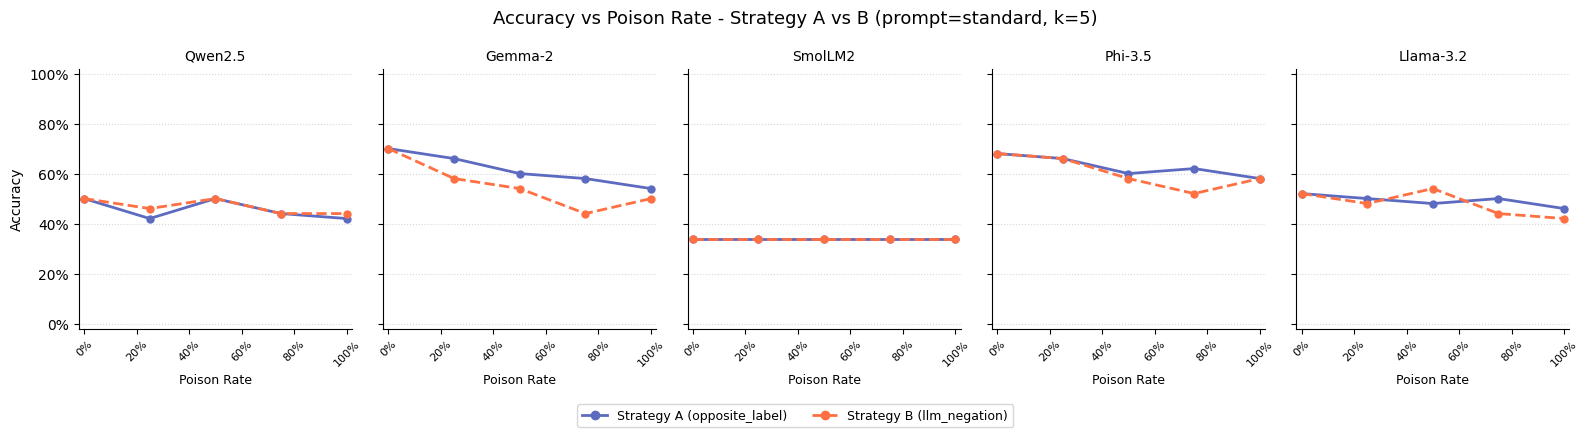

In [5]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for strategy in ["opposite_label", "llm_negation"]:
        sub = results[
            (results["model"] == model) & (results["strategy"] == strategy)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["accuracy"],
            marker="o", linewidth=2, markersize=5,
            color=STRATEGY_COLORS[strategy],
            linestyle=STRATEGY_STYLES[strategy],
            label=STRATEGY_LABELS[strategy],
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Accuracy")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=STRATEGY_COLORS[s], marker="o", linewidth=2,
               linestyle=STRATEGY_STYLES[s], label=STRATEGY_LABELS[s])
    for s in ["opposite_label", "llm_negation"]
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(
    f"Accuracy vs Poison Rate - Strategy A vs B (prompt={PROMPT_TYPE}, k={K})", fontsize=13
)
plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/07_strategy_comparison_accuracy.png", dpi=150, bbox_inches="tight")
    print("Saved -> figures/07_strategy_comparison_accuracy.png")
plt.show()

Saved -> figures/07_strategy_comparison_hallucination.png


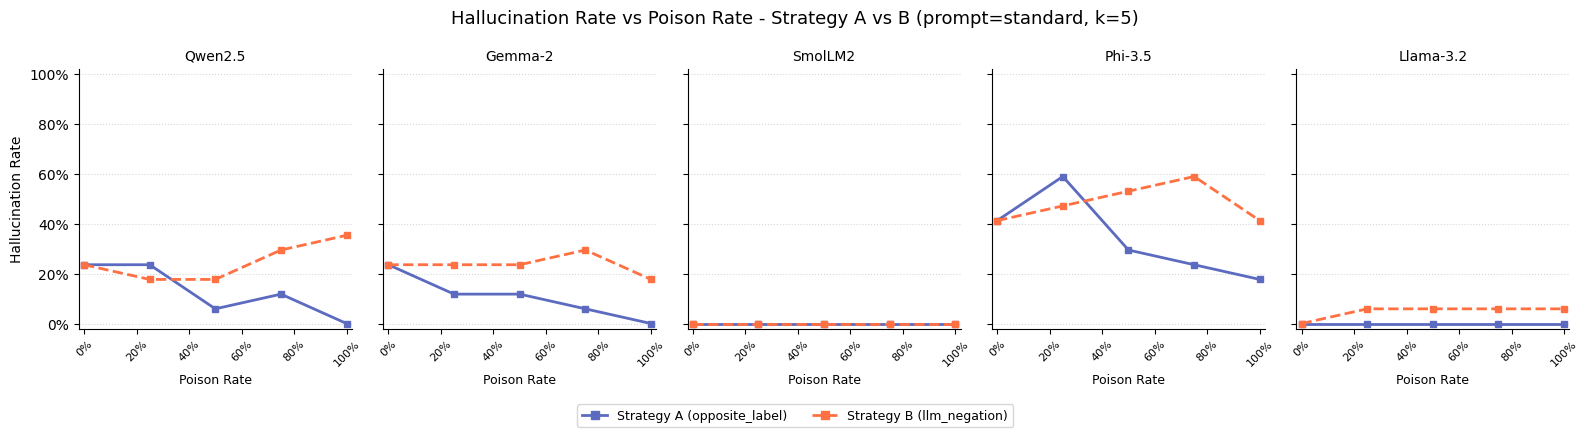

In [6]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for strategy in ["opposite_label", "llm_negation"]:
        sub = results[
            (results["model"] == model) & (results["strategy"] == strategy)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["hallucination_rate"],
            marker="s", linewidth=2, markersize=5,
            color=STRATEGY_COLORS[strategy],
            linestyle=STRATEGY_STYLES[strategy],
            label=STRATEGY_LABELS[strategy],
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Hallucination Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=STRATEGY_COLORS[s], marker="s", linewidth=2,
               linestyle=STRATEGY_STYLES[s], label=STRATEGY_LABELS[s])
    for s in ["opposite_label", "llm_negation"]
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(
    f"Hallucination Rate vs Poison Rate - Strategy A vs B (prompt={PROMPT_TYPE}, k={K})", fontsize=13
)
plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/07_strategy_comparison_hallucination.png", dpi=150, bbox_inches="tight")
    print("Saved -> figures/07_strategy_comparison_hallucination.png")
plt.show()

In [7]:
pivot_acc = results.pivot_table(
    index="strategy",
    columns="model",
    values="accuracy",
    aggfunc="mean",
)
pivot_acc.columns = [MODEL_LABELS[m] for m in pivot_acc.columns]
pivot_acc.index = [STRATEGY_LABELS[s] for s in pivot_acc.index]

print("=== Mean Accuracy by Strategy x Model (averaged over all poison rates) ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))
print()

delta = (
    pivot_acc.loc[STRATEGY_LABELS["llm_negation"]]
    - pivot_acc.loc[STRATEGY_LABELS["opposite_label"]]
)
print("=== Accuracy Delta (Strategy B - Strategy A) ===")
print(delta.to_string(float_format="{:+.3f}".format))

=== Mean Accuracy by Strategy x Model (averaged over all poison rates) ===
                             SmolLM2  Qwen2.5  Gemma-2  Llama-3.2  Phi-3.5
Strategy B (llm_negation)      0.340    0.468    0.552      0.480    0.604
Strategy A (opposite_label)    0.340    0.456    0.616      0.492    0.628

=== Accuracy Delta (Strategy B - Strategy A) ===
SmolLM2     +0.000
Qwen2.5     +0.012
Gemma-2     -0.064
Llama-3.2   -0.012
Phi-3.5     -0.024


## Qualitative Examples - Strategy A vs B Poisoned Passages
Both strategies at `poison_rate=1.0` (all evidence replaced) to make the contrast maximal. No new inference cost.

In [8]:
QUAL_EXAMPLES = all_examples[:min(5, N_EXAMPLES)]
QUAL_MODEL    = MODELS[0]  # Qwen2.5 - negations cached from sweep above

llm_qual = build_llm(QUAL_MODEL)
with llm_qual:
    poisoned_a = poison_dataset(
        QUAL_EXAMPLES, poison_rate=1.0, seed=SEED, strategy="opposite_label"
    )
    poisoned_b = poison_dataset(
        QUAL_EXAMPLES, poison_rate=1.0, seed=SEED,
        strategy="llm_negation", llm=llm_qual,
    )

print(f"Built poisoned examples for {len(QUAL_EXAMPLES)} claims.")

Built poisoned examples for 5 claims.


In [9]:
SEP = "=" * 72

for i, (orig, pa, pb) in enumerate(zip(QUAL_EXAMPLES, poisoned_a, poisoned_b), 1):
    print(f"\n{SEP}")
    print(f"  Example {i}")
    print(SEP)
    print(f"  CLAIM : {orig['claim']}")
    print(f"  LABEL : {orig['label']}")
    for j, (ev_orig, ev_a, ev_b) in enumerate(
        zip(orig["evidence"], pa["evidence"], pb["evidence"]), 1
    ):
        print(f"\n  Passage {j}:")
        print(f"    ORIGINAL   : {ev_orig[:130]}")
        print(f"    Strategy A : {ev_a[:130]}")
        print(f"    Strategy B : {ev_b[:130]}")


  Example 1
  CLAIM : Jackie (2016 film) was directed by Peter Jackson.
  LABEL : REFUTES

  Passage 1:
    ORIGINAL   : Jackie is a 2016 biographical drama film directed by Pablo Larraín and written by Noah Oppenheim .
    Strategy A : At the 2010 census , the city population was 145,170 , and its metropolitan area had a population of 662,577 .
    Strategy B : Pablo Larraín directed the 2016 biographical drama film "Jackie" with Noah Oppenheim writing it.

  Example 2
  CLAIM : The CONCACAF Champions League is organized for the top baseball clubs.
  LABEL : REFUTES

  Passage 1:
    ORIGINAL   : The CONCACAF Champions League is an annual continental football club competition organized by CONCACAF for the top football clubs 
    Strategy A : At the 2010 census , the city population was 145,170 , and its metropolitan area had a population of 662,577 .
    Strategy B : The CARIBBEAN CHAMPIONS LEAGUE is a biennial regional soccer tournament managed by FIFA for elite teams across South A

## Findings

Strategy B (llm_negation) is marginally harder than Strategy A on most models: mean accuracy delta ranges from -0.064 (Gemma-2) to +0.012 (Qwen2.5). SmolLM2 is unaffected (delta=0.000), confirming it ignores retrieved context regardless of distractor quality.

Qualitatively, Strategy B negations preserve the subject and surface form of the original passage while inverting the predicate, making them harder to dismiss than Strategy A's unrelated distractors. The small accuracy drop despite this increased semantic proximity suggests the models are weakly grounded in retrieved evidence, consistent with the NEI-collapse pattern observed in notebook 05.